<a href="https://colab.research.google.com/github/belokonr/Minimum-Wage-Project/blob/main/notebooks/03_Extension_and_Results_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Expansion and Results
This notebook expands upon the replication of Card and Krueger's original analysis. Specifically, I aimed to further study Heterogeneous Treatment Effects (HTE) in the data, highlighting factors that may have influenced employment in tandem with wage by interacting them with the GAP variable previously created, then presenting the results as a forest plot of heterogeneous treatment coefficients with confidence intervals. To perform this expansion, I employed Generative AI tools using the Claude Opus 4.6 model with the following prompt:

I have replicated the research described in the attached pdf file. I am looking to expand upon this research by expanding upon Heterogeneous Treatment Effects. My goal is to examine how the employment effect varies across other store characteristics that the authors collected: chain identity, ownership structure, initial store size, and geographic subregion within New Jersey. I would like to interact the GAP variable with each of these variables, then present the results as a forest plot of heterogeneous treatment coefficients with confidence intervals or in another suitable visual format. Please create python code that builds off of the code in the attached python notebook to implement these expansions.

Regression sample size: 351
  NJ stores: 285
  PA stores: 66

Median initial FTE: 19.5
  Large stores (>= median): 182
  Small stores (< median):  169

HETEROGENEOUS TREATMENT EFFECTS: GAP × STORE CHARACTERISTICS
Base specification controls: chain dummies + company-ownership dummy
Dependent variable: change in FTE employment (DEMP)
Standard errors clustered by store (SHEET)

--- Model A: Base (Table 4 col iv replication) ---
  GAP:    16.36  (SE 6.54)
  N = 351

--- Model B: GAP × Chain Identity ---
  GAP (Wendy's, omitted):   23.61  (SE 21.43)
  GAP × BK:                 -0.34  (SE 24.27)
  GAP × KFC:               -38.05  (SE 22.87)
  GAP × Roy Rogers:          4.44  (SE 23.62)
  -> Total GAP effect for Wendy's        :   23.61  (SE 21.43)
  -> Total GAP effect for Burger King    :   23.27  (SE 11.42)
  -> Total GAP effect for KFC            :  -14.44  (SE 7.94)
  -> Total GAP effect for Roy Rogers     :   28.05  (SE 10.01)
  F-test (chain interactions = 0): F = 4.81, p = 0.003

--- 

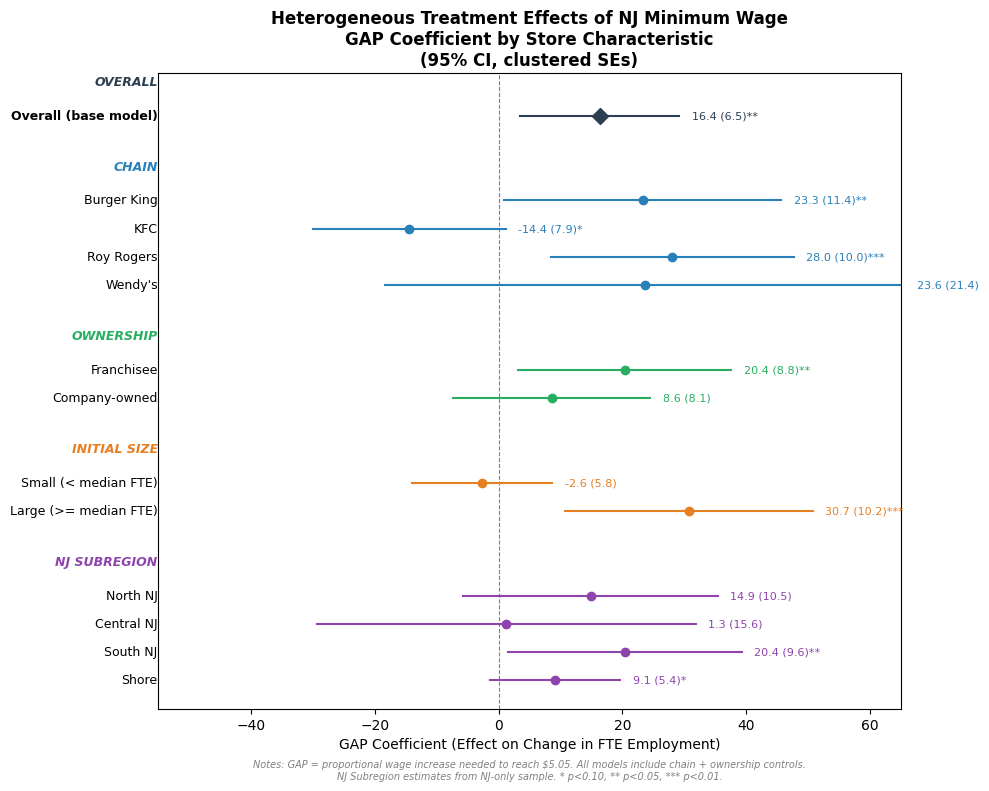

Forest plot saved as 'hte_forest_plot.png'

SUMMARY: INTERACTION COEFFICIENTS (GAP × Characteristic)
Interaction Term             Coeff       SE   t-stat    p-val
------------------------------------------------------------
GAP × BK                     -0.34    24.27    -0.01    0.989
GAP × KFC                   -38.05    22.87    -1.66    0.096
GAP × Roy Rogers              4.44    23.62     0.19    0.851
GAP × Co-owned              -11.74    11.69    -1.00    0.315
GAP × Large store            33.36    11.50     2.90    0.004
GAP × North NJ                5.72     8.87     0.64    0.519
GAP × Central NJ             -7.88    12.19    -0.65    0.518
GAP × South NJ               11.29     8.55     1.32    0.186

JOINT F-TESTS FOR HETEROGENEITY
  Chain interactions = 0:     F = 4.81, p = 0.003
  Region interactions = 0:    F = 2.07, p = 0.104
  All interactions = 0:       F = 3.48, p = 0.004


In [1]:
# ============================================================================
# Heterogeneous Treatment Effects Analysis
# Extension of Card & Krueger (1994) Replication
# ============================================================================
# This script builds on the replication notebook to examine how the employment
# effect of the NJ minimum wage varies across store characteristics:
#   1. Chain identity (BK, KFC, Roy Rogers, Wendy's)
#   2. Ownership structure (company-owned vs franchisee)
#   3. Initial store size (above/below median FTE)
#   4. Geographic subregion within NJ (North, Central, South, Shore)
# ============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── 1. DATA LOADING & VARIABLE CONSTRUCTION ─────────────────────────────────
# (Reproduced from the replication notebook)

colspecs = [
    (0, 3), (4, 5), (6, 7), (8, 9), (10, 11), (12, 13), (14, 15),
    (16, 17), (18, 19), (20, 21), (22, 24), (25, 30), (31, 36),
    (37, 42), (43, 48), (49, 54), (55, 60), (61, 62), (63, 68),
    (69, 70), (71, 76), (77, 82), (83, 88), (89, 94), (95, 100),
    (101, 103), (104, 106), (107, 108), (109, 110), (111, 117),
    (118, 120), (121, 126), (127, 132), (133, 138), (139, 144),
    (145, 150), (151, 156), (157, 158), (159, 160), (161, 166),
    (167, 172), (173, 178), (179, 184), (185, 190), (191, 193),
    (194, 196),
]

colnames = [
    'SHEET', 'CHAIN', 'CO_OWNED', 'STATE',
    'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE',
    'NCALLS', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST', 'INCTIME',
    'FIRSTINC', 'BONUS', 'PCTAFF', 'MEALS', 'OPEN', 'HRSOPEN',
    'PSODA', 'PFRY', 'PENTREE', 'NREGS', 'NREGS11',
    'TYPE2', 'STATUS2', 'DATE2', 'NCALLS2', 'EMPFT2', 'EMPPT2',
    'NMGRS2', 'WAGE_ST2', 'INCTIME2', 'FIRSTIN2', 'SPECIAL2',
    'MEALS2', 'OPEN2R', 'HRSOPEN2', 'PSODA2', 'PFRY2', 'PENTREE2',
    'NREGS2', 'NREGS112'
]

url = 'https://raw.githubusercontent.com/belokonr/Minimum-Wage-Project/refs/heads/main/data/raw/public.dat'

df = pd.read_fwf(url, colspecs=colspecs, names=colnames, na_values=['.'])

# Derived variables
df['EMPTOT'] = df['EMPPT'] * 0.5 + df['EMPFT'] + df['NMGRS']
df['EMPTOT2'] = df['EMPPT2'] * 0.5 + df['EMPFT2'] + df['NMGRS2']
df['DEMP'] = df['EMPTOT2'] - df['EMPTOT']

df['GAP'] = np.nan
df.loc[df['STATE'] == 0, 'GAP'] = 0
df.loc[(df['STATE'] == 1) & (df['WAGE_ST'] >= 5.05), 'GAP'] = 0
mask = (df['STATE'] == 1) & (df['WAGE_ST'] > 0) & (df['WAGE_ST'] < 5.05)
df.loc[mask, 'GAP'] = (5.05 - df.loc[mask, 'WAGE_ST']) / df.loc[mask, 'WAGE_ST']

df['NJ'] = df['STATE']
df['BK'] = (df['CHAIN'] == 1).astype(int)
df['KFC'] = (df['CHAIN'] == 2).astype(int)
df['ROYS'] = (df['CHAIN'] == 3).astype(int)
df['WENDYS'] = (df['CHAIN'] == 4).astype(int)

# Restrict to regression sample (valid employment + wage data in both waves)
reg_df = df.dropna(subset=['DEMP', 'WAGE_ST', 'WAGE_ST2', 'EMPTOT', 'EMPTOT2']).copy()

print(f"Regression sample size: {len(reg_df)}")
print(f"  NJ stores: {(reg_df['NJ'] == 1).sum()}")
print(f"  PA stores: {(reg_df['NJ'] == 0).sum()}")

# ── 2. ADDITIONAL VARIABLES FOR HTE ANALYSIS ────────────────────────────────

# Initial store size: above/below median FTE in wave 1
median_emp = reg_df['EMPTOT'].median()
reg_df['LARGE'] = (reg_df['EMPTOT'] >= median_emp).astype(int)
print(f"\nMedian initial FTE: {median_emp:.1f}")
print(f"  Large stores (>= median): {reg_df['LARGE'].sum()}")
print(f"  Small stores (< median):  {(1 - reg_df['LARGE']).sum()}")

# NJ subregion dummies (only meaningful for NJ stores)
# NORTHJ, CENTRALJ, SOUTHJ, SHORE are already in the data
# For PA stores, all NJ region dummies are 0

# Chain labels for display
reg_df['CHAIN_LABEL'] = reg_df['CHAIN'].map(
    {1: 'Burger King', 2: 'KFC', 3: 'Roy Rogers', 4: "Wendy's"}
)

# Interaction terms: GAP × each characteristic
reg_df['GAP_BK'] = reg_df['GAP'] * reg_df['BK']
reg_df['GAP_KFC'] = reg_df['GAP'] * reg_df['KFC']
reg_df['GAP_ROYS'] = reg_df['GAP'] * reg_df['ROYS']
# Wendy's is the omitted chain category

reg_df['GAP_CO_OWNED'] = reg_df['GAP'] * reg_df['CO_OWNED']
reg_df['GAP_LARGE'] = reg_df['GAP'] * reg_df['LARGE']

reg_df['GAP_NORTHJ'] = reg_df['GAP'] * reg_df['NORTHJ']
reg_df['GAP_CENTRALJ'] = reg_df['GAP'] * reg_df['CENTRALJ']
reg_df['GAP_SOUTHJ'] = reg_df['GAP'] * reg_df['SOUTHJ']
# Shore is the omitted NJ region category


# ── 3. HETEROGENEOUS TREATMENT EFFECTS MODELS ───────────────────────────────

print("\n" + "=" * 72)
print("HETEROGENEOUS TREATMENT EFFECTS: GAP × STORE CHARACTERISTICS")
print("=" * 72)
print("Base specification controls: chain dummies + company-ownership dummy")
print("Dependent variable: change in FTE employment (DEMP)")
print("Standard errors clustered by store (SHEET)")

# --- Model A: Base (replicates Table 4, col iv) ---
mA = smf.ols('DEMP ~ GAP + BK + KFC + ROYS + CO_OWNED', data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['SHEET']})
print(f"\n--- Model A: Base (Table 4 col iv replication) ---")
print(f"  GAP:  {mA.params['GAP']:7.2f}  (SE {mA.bse['GAP']:.2f})")
print(f"  N = {int(mA.nobs)}")

# --- Model B: GAP × Chain ---
mB = smf.ols('DEMP ~ GAP + GAP_BK + GAP_KFC + GAP_ROYS + BK + KFC + ROYS + CO_OWNED',
             data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['SHEET']})
print(f"\n--- Model B: GAP × Chain Identity ---")
print(f"  GAP (Wendy's, omitted): {mB.params['GAP']:7.2f}  (SE {mB.bse['GAP']:.2f})")
print(f"  GAP × BK:               {mB.params['GAP_BK']:7.2f}  (SE {mB.bse['GAP_BK']:.2f})")
print(f"  GAP × KFC:              {mB.params['GAP_KFC']:7.2f}  (SE {mB.bse['GAP_KFC']:.2f})")
print(f"  GAP × Roy Rogers:       {mB.params['GAP_ROYS']:7.2f}  (SE {mB.bse['GAP_ROYS']:.2f})")

# Compute chain-specific GAP effects (base + interaction)
chain_effects = {}
for chain, ivar in [("Wendy's", None), ("Burger King", 'GAP_BK'),
                     ("KFC", 'GAP_KFC'), ("Roy Rogers", 'GAP_ROYS')]:
    if ivar is None:
        coef = mB.params['GAP']
        se = mB.bse['GAP']
    else:
        coef = mB.params['GAP'] + mB.params[ivar]
        # SE via delta method: Var(b1+b2) = Var(b1) + Var(b2) + 2Cov(b1,b2)
        v = mB.cov_params().loc['GAP', 'GAP'] + \
            mB.cov_params().loc[ivar, ivar] + \
            2 * mB.cov_params().loc['GAP', ivar]
        se = np.sqrt(v)
    chain_effects[chain] = (coef, se)
    print(f"  -> Total GAP effect for {chain:15s}: {coef:7.2f}  (SE {se:.2f})")

# F-test for joint significance of chain interactions
f_chain = mB.f_test('GAP_BK = GAP_KFC = GAP_ROYS = 0')
print(f"  F-test (chain interactions = 0): F = {f_chain.fvalue:.2f}, p = {f_chain.pvalue:.3f}")

# --- Model C: GAP × Ownership ---
mC = smf.ols('DEMP ~ GAP + GAP_CO_OWNED + BK + KFC + ROYS + CO_OWNED',
             data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['SHEET']})
print(f"\n--- Model C: GAP × Ownership Structure ---")
print(f"  GAP (franchisee, omitted): {mC.params['GAP']:7.2f}  (SE {mC.bse['GAP']:.2f})")
print(f"  GAP × Company-owned:       {mC.params['GAP_CO_OWNED']:7.2f}  (SE {mC.bse['GAP_CO_OWNED']:.2f})")

own_effects = {}
# Franchisee
own_effects['Franchisee'] = (mC.params['GAP'], mC.bse['GAP'])
# Company-owned
coef_co = mC.params['GAP'] + mC.params['GAP_CO_OWNED']
v_co = mC.cov_params().loc['GAP', 'GAP'] + \
       mC.cov_params().loc['GAP_CO_OWNED', 'GAP_CO_OWNED'] + \
       2 * mC.cov_params().loc['GAP', 'GAP_CO_OWNED']
own_effects['Company-owned'] = (coef_co, np.sqrt(v_co))
for k, (c, s) in own_effects.items():
    print(f"  -> Total GAP effect for {k:18s}: {c:7.2f}  (SE {s:.2f})")

# --- Model D: GAP × Initial Store Size ---
mD = smf.ols('DEMP ~ GAP + GAP_LARGE + LARGE + BK + KFC + ROYS + CO_OWNED',
             data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['SHEET']})
print(f"\n--- Model D: GAP × Initial Store Size ---")
print(f"  GAP (small stores, omitted): {mD.params['GAP']:7.2f}  (SE {mD.bse['GAP']:.2f})")
print(f"  GAP × Large:                 {mD.params['GAP_LARGE']:7.2f}  (SE {mD.bse['GAP_LARGE']:.2f})")

size_effects = {}
size_effects['Small (< median FTE)'] = (mD.params['GAP'], mD.bse['GAP'])
coef_lg = mD.params['GAP'] + mD.params['GAP_LARGE']
v_lg = mD.cov_params().loc['GAP', 'GAP'] + \
       mD.cov_params().loc['GAP_LARGE', 'GAP_LARGE'] + \
       2 * mD.cov_params().loc['GAP', 'GAP_LARGE']
size_effects['Large (>= median FTE)'] = (coef_lg, np.sqrt(v_lg))
for k, (c, s) in size_effects.items():
    print(f"  -> Total GAP effect for {k:22s}: {c:7.2f}  (SE {s:.2f})")

# --- Model E: GAP × NJ Subregion (NJ stores only) ---
nj_df = reg_df[reg_df['NJ'] == 1].copy()
mE = smf.ols('DEMP ~ GAP + GAP_NORTHJ + GAP_CENTRALJ + GAP_SOUTHJ + '
             'NORTHJ + CENTRALJ + SOUTHJ + BK + KFC + ROYS + CO_OWNED',
             data=nj_df).fit(
    cov_type='cluster', cov_kwds={'groups': nj_df['SHEET']})
print(f"\n--- Model E: GAP × NJ Subregion (NJ stores only, N={int(mE.nobs)}) ---")
print(f"  GAP (Shore, omitted):    {mE.params['GAP']:7.2f}  (SE {mE.bse['GAP']:.2f})")
print(f"  GAP × North NJ:         {mE.params['GAP_NORTHJ']:7.2f}  (SE {mE.bse['GAP_NORTHJ']:.2f})")
print(f"  GAP × Central NJ:       {mE.params['GAP_CENTRALJ']:7.2f}  (SE {mE.bse['GAP_CENTRALJ']:.2f})")
print(f"  GAP × South NJ:         {mE.params['GAP_SOUTHJ']:7.2f}  (SE {mE.bse['GAP_SOUTHJ']:.2f})")

region_effects = {}
region_effects['Shore'] = (mE.params['GAP'], mE.bse['GAP'])
for reg, ivar in [('North NJ', 'GAP_NORTHJ'), ('Central NJ', 'GAP_CENTRALJ'),
                   ('South NJ', 'GAP_SOUTHJ')]:
    coef_r = mE.params['GAP'] + mE.params[ivar]
    v_r = mE.cov_params().loc['GAP', 'GAP'] + \
          mE.cov_params().loc[ivar, ivar] + \
          2 * mE.cov_params().loc['GAP', ivar]
    region_effects[reg] = (coef_r, np.sqrt(v_r))
for k, (c, s) in region_effects.items():
    print(f"  -> Total GAP effect for {k:15s}: {c:7.2f}  (SE {s:.2f})")

f_region = mE.f_test('GAP_NORTHJ = GAP_CENTRALJ = GAP_SOUTHJ = 0')
print(f"  F-test (region interactions = 0): F = {f_region.fvalue:.2f}, p = {f_region.pvalue:.3f}")


# ── 4. FULLY INTERACTED MODEL (KITCHEN SINK) ───────────────────────────────

print(f"\n--- Model F: Fully Interacted (all interactions jointly) ---")
mF = smf.ols('DEMP ~ GAP + GAP_BK + GAP_KFC + GAP_ROYS + GAP_CO_OWNED + GAP_LARGE + '
             'BK + KFC + ROYS + CO_OWNED + LARGE', data=reg_df).fit(
    cov_type='cluster', cov_kwds={'groups': reg_df['SHEET']})
print(f"  N = {int(mF.nobs)}")
for v in ['GAP', 'GAP_BK', 'GAP_KFC', 'GAP_ROYS', 'GAP_CO_OWNED', 'GAP_LARGE']:
    print(f"  {v:18s}: {mF.params[v]:7.2f}  (SE {mF.bse[v]:.2f})")
f_all = mF.f_test('GAP_BK = GAP_KFC = GAP_ROYS = GAP_CO_OWNED = GAP_LARGE = 0')
print(f"  F-test (all interactions = 0): F = {f_all.fvalue:.2f}, p = {f_all.pvalue:.3f}")


# ── 5. FOREST PLOT ──────────────────────────────────────────────────────────

print("\n" + "=" * 72)
print("GENERATING FOREST PLOT...")
print("=" * 72)

# Collect all results for the forest plot
# Each entry: (label, coefficient, SE, category)
plot_data = []

# Overall baseline
plot_data.append(('Overall (base model)', mA.params['GAP'], mA.bse['GAP'], 'Overall'))

# Chain effects
for chain in ["Burger King", "KFC", "Roy Rogers", "Wendy's"]:
    c, s = chain_effects[chain]
    plot_data.append((chain, c, s, 'Chain'))

# Ownership effects
for own in ['Franchisee', 'Company-owned']:
    c, s = own_effects[own]
    plot_data.append((own, c, s, 'Ownership'))

# Size effects
for sz in ['Small (< median FTE)', 'Large (>= median FTE)']:
    c, s = size_effects[sz]
    plot_data.append((sz, c, s, 'Initial Size'))

# Region effects (NJ only)
for reg in ['North NJ', 'Central NJ', 'South NJ', 'Shore']:
    c, s = region_effects[reg]
    plot_data.append((reg, c, s, 'NJ Subregion'))

# Build the plot
labels = [d[0] for d in plot_data]
coefs = np.array([d[1] for d in plot_data])
ses = np.array([d[2] for d in plot_data])
cats = [d[3] for d in plot_data]

ci_lo = coefs - 1.96 * ses
ci_hi = coefs + 1.96 * ses

# Color mapping by category
cat_colors = {
    'Overall': '#2c3e50',
    'Chain': '#2980b9',
    'Ownership': '#27ae60',
    'Initial Size': '#e67e22',
    'NJ Subregion': '#8e44ad',
}

fig, ax = plt.subplots(figsize=(10, 8))

y_positions = np.arange(len(labels))[::-1]  # top to bottom

# Add category separators and headers
current_cat = None
header_positions = {}
offset = 0
adjusted_y = []
header_y = {}

# Calculate positions with gaps between categories
pos = len(labels) + 4  # start from top
for i, (label, coef, se, cat) in enumerate(plot_data):
    if cat != current_cat:
        if current_cat is not None:
            pos -= 0.8  # gap between categories
        header_y[cat] = pos
        pos -= 1.2  # space for header
        current_cat = cat
    adjusted_y.append(pos)
    pos -= 1

adjusted_y = np.array(adjusted_y)

# Draw
for i, (label, coef, se, cat) in enumerate(plot_data):
    y = adjusted_y[i]
    color = cat_colors[cat]

    # CI line
    ax.plot([ci_lo[i], ci_hi[i]], [y, y], color=color, linewidth=1.5, zorder=2)

    # Point estimate
    marker = 'D' if cat == 'Overall' else 'o'
    ms = 8 if cat == 'Overall' else 6
    ax.plot(coef, y, marker, color=color, markersize=ms, zorder=3)

    # Label
    ax.text(-55, y, label, va='center', ha='right', fontsize=9,
            fontweight='bold' if cat == 'Overall' else 'normal')

    # Coefficient annotation
    sig = ''
    if abs(coef / se) > 2.576:
        sig = '***'
    elif abs(coef / se) > 1.96:
        sig = '**'
    elif abs(coef / se) > 1.645:
        sig = '*'
    ax.text(max(ci_hi[i], 0) + 2, y,
            f'{coef:.1f} ({se:.1f}){sig}',
            va='center', ha='left', fontsize=8, color=color)

# Category headers
for cat, y in header_y.items():
    ax.text(-55, y, cat.upper(), va='center', ha='right',
            fontsize=9, fontweight='bold', color=cat_colors[cat],
            fontstyle='italic')

# Zero line
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, zorder=1)

# Formatting
ax.set_xlim(-55, 65)
ax.set_ylim(min(adjusted_y) - 1, max(adjusted_y) + 1.5)
ax.set_yticks([])
ax.set_xlabel('GAP Coefficient (Effect on Change in FTE Employment)', fontsize=10)
ax.set_title('Heterogeneous Treatment Effects of NJ Minimum Wage\n'
             'GAP Coefficient by Store Characteristic\n'
             '(95% CI, clustered SEs)',
             fontsize=12, fontweight='bold')

# Add note
ax.text(0.5, -0.08,
        'Notes: GAP = proportional wage increase needed to reach $5.05. '
        'All models include chain + ownership controls.\n'
        'NJ Subregion estimates from NJ-only sample. '
        '* p<0.10, ** p<0.05, *** p<0.01.',
        transform=ax.transAxes, fontsize=7, ha='center', va='top',
        style='italic', color='gray')

plt.tight_layout()
plt.savefig('hte_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forest plot saved as 'hte_forest_plot.png'")


# ── 6. SUMMARY TABLE ────────────────────────────────────────────────────────

print("\n" + "=" * 72)
print("SUMMARY: INTERACTION COEFFICIENTS (GAP × Characteristic)")
print("=" * 72)
print(f"{'Interaction Term':<25s} {'Coeff':>8s} {'SE':>8s} {'t-stat':>8s} {'p-val':>8s}")
print("-" * 60)

interaction_terms = [
    ('GAP × BK', mB, 'GAP_BK'),
    ('GAP × KFC', mB, 'GAP_KFC'),
    ('GAP × Roy Rogers', mB, 'GAP_ROYS'),
    ('GAP × Co-owned', mC, 'GAP_CO_OWNED'),
    ('GAP × Large store', mD, 'GAP_LARGE'),
    ('GAP × North NJ', mE, 'GAP_NORTHJ'),
    ('GAP × Central NJ', mE, 'GAP_CENTRALJ'),
    ('GAP × South NJ', mE, 'GAP_SOUTHJ'),
]

for label, model, var in interaction_terms:
    c = model.params[var]
    s = model.bse[var]
    t = model.tvalues[var]
    p = model.pvalues[var]
    print(f"{label:<25s} {c:8.2f} {s:8.2f} {t:8.2f} {p:8.3f}")

print("\n" + "=" * 72)
print("JOINT F-TESTS FOR HETEROGENEITY")
print("=" * 72)
print(f"  Chain interactions = 0:     F = {f_chain.fvalue:.2f}, p = {f_chain.pvalue:.3f}")
print(f"  Region interactions = 0:    F = {f_region.fvalue:.2f}, p = {f_region.pvalue:.3f}")
print(f"  All interactions = 0:       F = {f_all.fvalue:.2f}, p = {f_all.pvalue:.3f}")

The heterogeneous treatment effects analysis largely reinforces Card and Krueger's central conclusion that the New Jersey minimum wage increase did not reduce employment while revealing that the effect was not uniform across all store types. The most striking finding is that initial store size strongly moderates the treatment effect: the GAP × Large interaction is statistically significant at the 1% level (coefficient 33.36, SE 11.50), indicating that larger stores experienced substantially greater employment gains in response to the wage floor. This could reflect the fact that bigger establishments had more low-wage workers exposed to the mandate and thus more scope for adjustment. The joint F-test for chain interactions is also significant (p = 0.003), driven primarily by KFC stores, which show a notably weaker (and marginally significant negative) differential response relative to the other chains, possibly reflecting KFC's smaller average size and different labor mix noted by the authors.

Across the other dimensions, the results suggest relative homogeneity. Ownership structure (company-owned vs. franchisee) and NJ subregion show no statistically significant heterogeneity individually, and the regional F-test fails to reject equality (p = 0.104). This is reassuring for the original paper's identification strategy: it suggests the positive employment effect was not driven by a particular region experiencing idiosyncratic demand shocks, nor by a specific ownership type behaving differently. Taken together, this extension contextualizes the original findings by showing that while the average effect is non-negative, the magnitude of the employment response was meaningfully larger at bigger stores and varied somewhat across chains. The core conclusion of there being no evidence of employment losses from the minimum wage increase holds across every subgroup examined.